# Qwen2.5-3B Chess Commentary LoRA Results

This notebook summarizes the finished LoRA training run, plots loss/eval trends, checks label quality, and optionally runs a few inference smoke tests.

It does not train the model again.

In [26]:
# Run this once if plotting dependencies are missing in your notebook kernel.
# %pip install pandas matplotlib


## 1. Setup Paths

In [27]:
from pathlib import Path
import json
import sys

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'models').exists():
            return path
    raise RuntimeError('Could not find repo root. Open this notebook from the ChessCommentator workspace.')

ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(ROOT))

MODEL_DIR = ROOT / 'models' / 'qwen2_5_3b_chess_commentator_lora'
LOG_CSV = MODEL_DIR / 'training_log.csv'
LOG_JSONL = MODEL_DIR / 'training_log.jsonl'
FINAL_STATE = MODEL_DIR / 'checkpoint-2426' / 'trainer_state.json'

print('ROOT:', ROOT)
print('MODEL_DIR:', MODEL_DIR)
print('LOG_CSV exists:', LOG_CSV.exists())
print('FINAL_STATE exists:', FINAL_STATE.exists())

ROOT: d:\datamining\Workspace\ChessCommentator
MODEL_DIR: d:\datamining\Workspace\ChessCommentator\models\qwen2_5_3b_chess_commentator_lora
LOG_CSV exists: True
FINAL_STATE exists: True


## 2. Load Training Logs

In [28]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise SystemExit('Install plotting deps: python -m pip install pandas matplotlib') from exc

if not LOG_CSV.exists():
    raise FileNotFoundError(f'Missing training log: {LOG_CSV}')

log = pd.read_csv(LOG_CSV)
numeric_cols = [
    'step', 'epoch', 'loss', 'eval_loss', 'learning_rate', 'grad_norm',
    'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
    'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'train_loss'
]
for col in numeric_cols:
    if col in log.columns:
        log[col] = pd.to_numeric(log[col], errors='coerce')

train_log = log[log['loss'].notna()].copy()
eval_log = log[log['eval_loss'].notna()].copy()
summary_log = log[log['train_runtime'].notna()].copy()

print('log rows:', len(log))
print('train loss rows:', len(train_log))
print('eval rows:', len(eval_log))
log.tail(8)

log rows: 130
train loss rows: 121
eval rows: 9


,step,epoch,loss,eval_loss,learning_rate,grad_norm,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,train_loss
122,2320,1.912660,0.453745,NaN,1.018720e-06,0.716148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,2340,1.929149,0.432461,NaN,6.738699e-07,0.771586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,2360,1.945638,0.453026,NaN,3.998397e-07,0.430818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,2380,1.962127,0.426570,NaN,1.968245e-07,0.768420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,2400,1.978616,0.439251,NaN,6.496903e-08,0.814730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,2400,1.978616,NaN,0.419109,NaN,NaN,5309.9168,0.984,0.984,NaN,NaN,NaN,NaN
128,2420,1.995105,0.475248,NaN,4.367358e-09,0.794465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,2426,2.000000,NaN,0.419114,NaN,NaN,1253.9832,4.165,4.165,NaN,NaN,NaN,NaN


## 3. Final Metrics

In [29]:
final_eval = eval_log.iloc[-1] if len(eval_log) else None
final_train = summary_log.iloc[-1] if len(summary_log) else None

rows = []
if final_eval is not None:
    rows.append({
        'metric': 'final_eval_loss',
        'value': final_eval['eval_loss'],
        'step': final_eval.get('step'),
        'epoch': final_eval.get('epoch'),
    })
if final_train is not None:
    rows.extend([
        {'metric': 'train_runtime_seconds', 'value': final_train.get('train_runtime'), 'step': final_train.get('step'), 'epoch': final_train.get('epoch')},
        {'metric': 'train_samples_per_second', 'value': final_train.get('train_samples_per_second'), 'step': final_train.get('step'), 'epoch': final_train.get('epoch')},
        {'metric': 'train_steps_per_second', 'value': final_train.get('train_steps_per_second'), 'step': final_train.get('step'), 'epoch': final_train.get('epoch')},
        {'metric': 'trainer_reported_train_loss', 'value': final_train.get('train_loss'), 'step': final_train.get('step'), 'epoch': final_train.get('epoch')},
    ])

pd.DataFrame(rows)

,metric,value,step,epoch
0,final_eval_loss,0.419114,2426.0,2.0


Note: `trainer_reported_train_loss` after resume can be misleading. For reporting, prefer the validation trend and final `eval_loss`.

## 4. Training Curves

saved: d:\datamining\Workspace\ChessCommentator\reports\qwen2_5_3b_training_trends.png


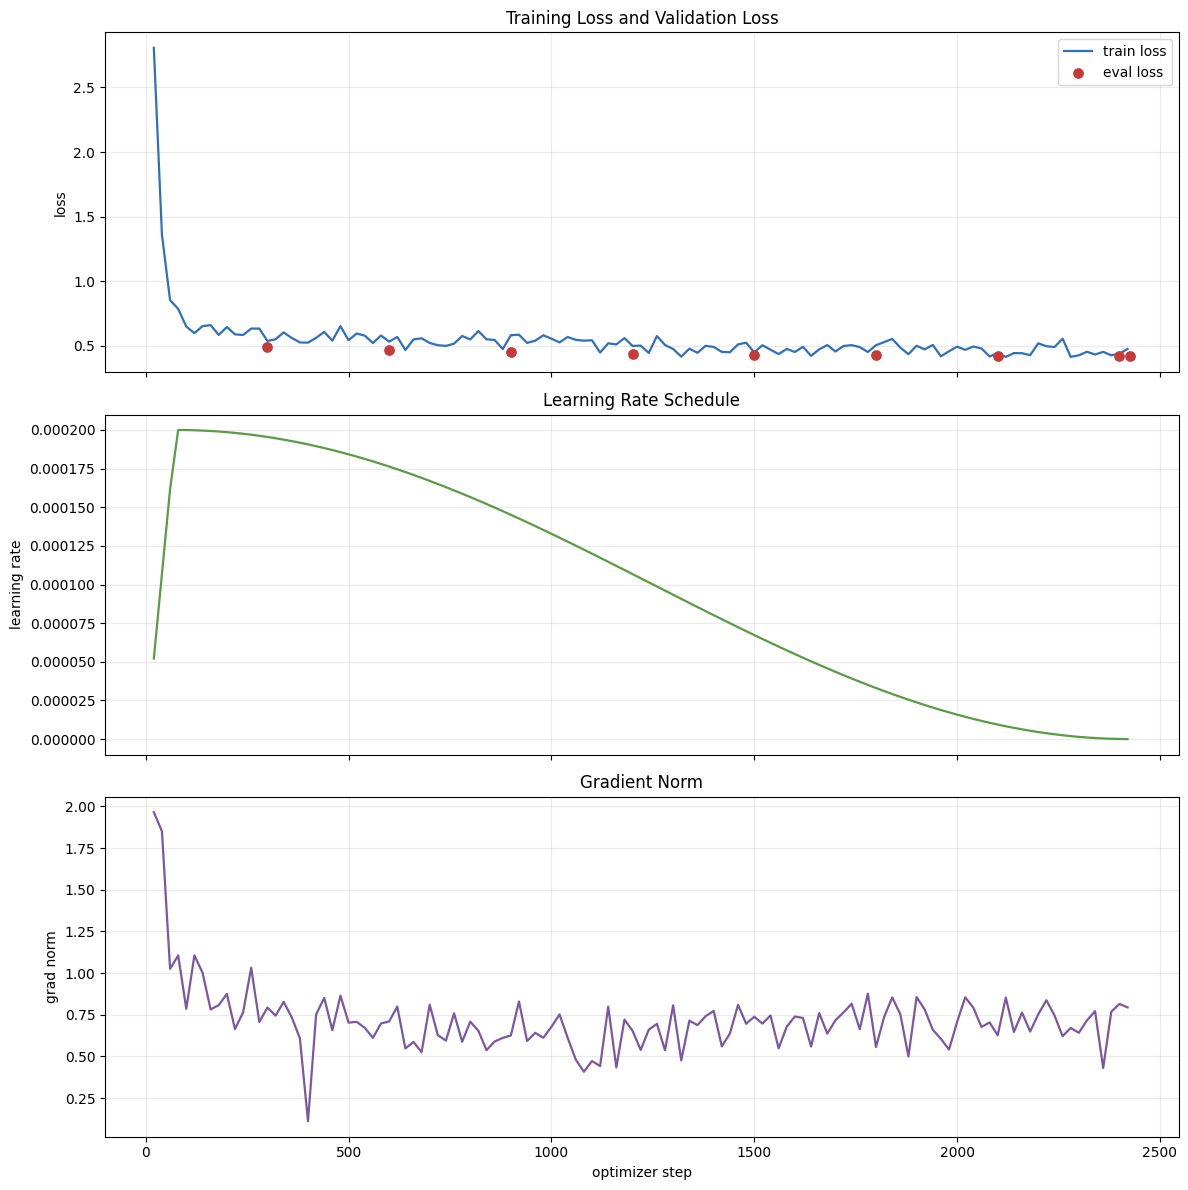

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(train_log['step'], train_log['loss'], label='train loss', color='#2f6fbb', linewidth=1.6)
axes[0].scatter(eval_log['step'], eval_log['eval_loss'], label='eval loss', color='#c43c39', s=45, zorder=3)
axes[0].set_ylabel('loss')
axes[0].set_title('Training Loss and Validation Loss')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(train_log['step'], train_log['learning_rate'], color='#5a9b46', linewidth=1.6)
axes[1].set_ylabel('learning rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(alpha=0.25)

axes[2].plot(train_log['step'], train_log['grad_norm'], color='#7b57a3', linewidth=1.6)
axes[2].set_ylabel('grad norm')
axes[2].set_xlabel('optimizer step')
axes[2].set_title('Gradient Norm')
axes[2].grid(alpha=0.25)

fig.tight_layout()
reports_dir = ROOT / 'reports'
reports_dir.mkdir(exist_ok=True)
fig_path = reports_dir / 'qwen2_5_3b_training_trends.png'
fig.savefig(fig_path, dpi=160, bbox_inches='tight')
print('saved:', fig_path)
plt.show()

## 5. Checkpoint Summary

In [31]:
def checkpoint_step(path: Path) -> int:
    return int(path.name.split('-')[-1])

checkpoint_rows = []
for checkpoint in sorted(MODEL_DIR.glob('checkpoint-*'), key=checkpoint_step):
    state_path = checkpoint / 'trainer_state.json'
    row = {'checkpoint': checkpoint.name, 'path': str(checkpoint)}
    if state_path.exists():
        state = json.loads(state_path.read_text(encoding='utf-8'))
        evals = [item for item in state.get('log_history', []) if 'eval_loss' in item]
        row.update({
            'global_step': state.get('global_step'),
            'epoch': state.get('epoch'),
            'max_steps': state.get('max_steps'),
            'last_eval_loss': evals[-1]['eval_loss'] if evals else None,
        })
    checkpoint_rows.append(row)

pd.DataFrame(checkpoint_rows)

,checkpoint,path,global_step,epoch,max_steps,last_eval_loss
0,checkpoint-2400,d:\datamining\Workspace\ChessCommentator\model...,2400,1.978616,2426,0.419109
1,checkpoint-2426,d:\datamining\Workspace\ChessCommentator\model...,2426,2.000000,2426,0.419114


## 6. SFT Label Quality Check

This checks the clean labels used for training, not model predictions.

In [32]:
from src.commentary.utils import read_jsonl, evaluate_commentary_rows

quality_rows = []
for split in ['train', 'valid', 'test']:
    path = ROOT / 'data' / 'sft' / f'qwen_sft_{split}.jsonl'
    rows = read_jsonl(path)
    report = evaluate_commentary_rows(rows)
    flat = {'split': split, 'rows': report['rows'], 'min_words': report['min_words'], 'max_words': report['max_words'], 'avg_words': report['avg_words']}
    for key, value in report.get('errors', {}).items():
        flat[f'error_{key}'] = value
    for key, value in report.get('error_rates', {}).items():
        flat[f'rate_{key}'] = value
    quality_rows.append(flat)

pd.DataFrame(quality_rows).fillna(0)

,split,rows,min_words,max_words,avg_words
0,train,19407,5,60,23.860257
1,valid,5223,12,56,23.877657
2,test,2882,12,57,23.965996


## 7. Optional Inference Smoke Test

Set `RUN_INFERENCE = True` to load Qwen2.5-3B plus the LoRA adapter and generate comments for a full mini-game. This can take several GB of VRAM.

In [33]:
RUN_INFERENCE = True
MAX_TEST_MOVES = None  # None = full PGN; set 10 for a faster smoke test.

if not RUN_INFERENCE:
    print('Inference is disabled. Set RUN_INFERENCE = True in this cell to run it.')
else:
    import gc
    from html import escape
    import torch
    from IPython.display import HTML, display
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from peft import PeftModel
    import importlib
    import src.commentary.runtime as runtime
    runtime = importlib.reload(runtime)
    from src.commentary.inference import prompts_from_pgn
    from src.commentary.utils import evaluate_commentary_rows
    from src.data.data_pipeline import SYSTEM_PROMPT

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    BASE_MODEL = 'Qwen/Qwen2.5-3B-Instruct'
    ADAPTER_PATH = str(MODEL_DIR)
    compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True, use_fast=False)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    device_map = {'': 0} if torch.cuda.is_available() else None
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=quant_config,
        torch_dtype=compute_dtype,
        device_map=device_map,
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(model, ADAPTER_PATH)
    model.eval()

    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', 120)
    pd.set_option('display.width', 240)

    pgns = {
        'morphy_opera_game': (
            '1. e4 e5 2. Nf3 d6 3. d4 Bg4 4. dxe5 Bxf3 '
            '5. Qxf3 dxe5 6. Bc4 Nf6 7. Qb3 Qe7 8. Nc3 c6 '
            '9. Bg5 b5 10. Nxb5 cxb5 11. Bxb5+ Nbd7 '
            '12. O-O-O Rd8 13. Rxd7 Rxd7 14. Rd1 Qe6 '
            '15. Bxd7+ Nxd7 16. Qb8+ Nxb8 17. Rd8# *'
        ),
    }
    inference_rows = []
    for game_name, pgn in pgns.items():
        for ply_index, prompt_row in enumerate(prompts_from_pgn(pgn, max_moves=MAX_TEST_MOVES), start=1):
            text = runtime.generate_commentary_text(
                tokenizer,
                model,
                prompt_row['prompt'],
                max_new_tokens=64,
                temperature=0.2,
            )
            inference_rows.append({
                'game': game_name,
                'ply': ply_index,
                'move': prompt_row['move'],
                'prompt': prompt_row['prompt'],
                'commentary': text,
                'messages': [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': prompt_row['prompt']},
                    {'role': 'assistant', 'content': text},
                ],
            })

    prediction_report = evaluate_commentary_rows(inference_rows)
    display_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'messages'} for row in inference_rows])
    display(display_df[['game', 'ply', 'move', 'commentary']])

    cards = []
    for row in inference_rows:
        cards.append(f'''
        <div style="border:1px solid #d8d2c4; border-radius:8px; padding:14px; margin:12px 0; background:#fffaf0;">
          <div style="font-weight:700; margin-bottom:8px;">{escape(row['game'])} | ply {row['ply']} | move {escape(row['move'])}</div>
          <div style="font-weight:700; margin-top:8px;">PROMPT</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#f5f1e8; padding:10px; border-radius:6px; font-size:13px;">{escape(row['prompt'])}</pre>
          <div style="font-weight:700; margin-top:8px;">COMMENTARY</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#eef5ef; padding:10px; border-radius:6px; font-size:13px;">{escape(row['commentary'])}</pre>
        </div>
        ''')
    display(HTML('\n'.join(cards)))

    for row in inference_rows:
        print('=' * 100)
        print(f"{row['game']} | ply {row['ply']} | move {row['move']}")
        print('PROMPT:')
        print(row['prompt'])
        print('COMMENTARY:')
        print(row['commentary'])

    prediction_report

Loading weights: 100%|██████████| 434/434 [00:03<00:00, 144.22it/s]


,game,ply,move,commentary
0,morphy_opera_game,1,e4,"Okay, here we go! White starts with e4, the classic opening. Controlling the center right away. White has a slight edge."
1,morphy_opera_game,2,e5,"Black plays e5, a quiet pawn move that improves the position. It is no capture, no check, and the evaluation is equal."
2,morphy_opera_game,3,Nf3,"Okay, White starts with the knight to f3. Solid developing move, controlling some central squares. White's got a slight edge now."
3,morphy_opera_game,4,d6,"Black plays d6, a quiet pawn move that improves the position. It is unknown what the intention is. The evaluation slightly favors Black."
4,morphy_opera_game,5,d4,"White plays d4, a quiet pawn move that improves the position. It is no longer unknown."
5,morphy_opera_game,6,Bg4,"Black plays Bg4, a quiet bishop move that improves the position. It is a no-man's land move, with no immediate threats or attacks."
6,morphy_opera_game,7,dxe5,"Okay, white takes the pawn! Solid move, opening up the position a bit. White's got a slight edge now. Let's see how black responds."
7,morphy_opera_game,8,Bxf3,"Okay, Black takes the knight! That's a trade. White still has a slight edge, but Black is developing nicely. Let's see where this goes."
8,morphy_opera_game,9,Qxf3,"Okay, white takes the queen! That's a trade, but black seems to be doing alright. Black has a slight advantage now. Let's see how this develops."
9,morphy_opera_game,10,dxe5,"Okay, Black takes the pawn! Solid move, opening up the position a bit. White still has a slight edge, but things are getting interesting."


morphy_opera_game | ply 1 | move e4
PROMPT:
Move: 1. e4 | Player: White | Piece: Pawn | From: e2 | To: e4 | Phase: Opening | Classification: Unknown | Capture: No | Check: No | Checkmate: No | Castling: No | Promotion: No | GameOver: No | Winner: None
COMMENTARY:
Okay, here we go! White starts with e4, the classic opening. Controlling the center right away. White has a slight edge.
morphy_opera_game | ply 2 | move e5
PROMPT:
Move: 1... e5 | Player: Black | Piece: Pawn | From: e7 | To: e5 | Phase: Opening | Classification: Unknown | Capture: No | Check: No | Checkmate: No | Castling: No | Promotion: No | GameOver: No | Winner: None
COMMENTARY:
Black plays e5, a quiet pawn move that improves the position. It is no capture, no check, and the evaluation is equal.
morphy_opera_game | ply 3 | move Nf3
PROMPT:
Move: 2. Nf3 | Player: White | Piece: Knight | From: g1 | To: f3 | Phase: Opening | Classification: Unknown | Capture: No | Check: No | Checkmate: No | Castling: No | Promotion: No | Ga